## Nazira Tukeyeva - Homework 3

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("biking_accidents.csv")

In [18]:
df.head()

,Accident Index,Date,Borough,Ward,Latitude,Longitude,Casualties,Severity,Number of Casualties,Number of Vehicles,...,cloud_cover,date,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,sunshine,DeadlyAccident
0,2019010161545,2019-02-04 19:55:00,Hounslow,Heston Central,51.475300,-0.375342,Cyclist,fatal,1,2,...,7.0,2019-02-04,20.0,9.5,4.2,-1.2,0.2,101850.0,0.0,1
1,2019010191515,2019-07-04 15:09:00,Lambeth,Clapham Town,51.468211,-0.144234,Cyclist,fatal,1,2,...,1.0,2019-07-04,36.0,27.6,19.4,12.0,0.0,102460.0,14.1,1
2,2019010209381,2019-10-03 17:05:00,Hillingdon,Northwood,51.612605,-0.434904,"Pedestrian,Cyclist",fatal,2,1,...,5.0,2019-10-03,45.0,15.7,9.7,4.0,1.8,101640.0,0.2,1
3,2019010214996,2019-10-30 06:39:00,Lewisham,Rushey Green,51.444015,-0.026135,Cyclist,fatal,1,2,...,5.0,2019-10-30,70.0,13.3,9.9,7.0,0.0,102400.0,4.4,1
4,2019010254652,2019-02-09 08:40:00,Camden,West Hampstead,51.550844,-0.191400,Cyclist,fatal,1,1,...,4.0,2019-02-09,61.0,8.0,8.7,6.5,2.0,100040.0,3.7,1


In [4]:
df.describe()

,Latitude,Longitude,Number of Casualties,Number of Vehicles,cycleway_15m,living_str_15m,motorway_15m,pedestrian_15m,primary_15m,resident_15m,...,trunk_25m,unclass_25m,cloud_cover,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,sunshine
count,60647.000000,60647.000000,60647.000000,60647.000000,60647.000000,60647.000000,60647.000000,60647.000000,60647.000000,60647.000000,...,60647.000000,60647.000000,60647.000000,60647.000000,60647.000000,60647.00000,60647.000000,60647.000000,60647.000000,60647.000000
mean,51.501755,-0.129739,1.035599,1.972843,0.177486,0.002605,0.000577,0.019985,0.428991,0.422972,...,0.243821,0.153363,4.585932,131.746879,17.211438,13.07823,8.846898,1.557307,101568.493083,4.848570
std,0.055217,0.111731,0.195257,0.266780,0.382083,0.050975,0.024016,0.139948,0.494936,0.494035,...,0.429389,0.360340,2.363337,89.097727,6.424096,5.53013,5.083037,3.588567,977.241767,4.104324
min,51.295232,-0.509746,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,12.000000,-1.200000,-4.10000,-9.400000,0.000000,97310.000000,0.000000
25%,51.468806,-0.187997,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,3.000000,50.000000,12.300000,8.90000,5.200000,0.000000,101010.000000,1.000000
50%,51.506685,-0.120487,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,5.000000,116.000000,17.600000,13.50000,9.300000,0.000000,101640.000000,4.200000
75%,51.535455,-0.070980,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,7.000000,203.000000,21.800000,17.30000,12.800000,1.400000,102215.000000,7.900000
max,51.684432,0.301900,6.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,9.000000,345.000000,37.900000,28.80000,22.300000,51.600000,104380.000000,15.300000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60647 entries, 0 to 60646
Data columns (total 65 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Accident Index        60647 non-null  object 
 1   Date                  60647 non-null  object 
 2   Borough               60647 non-null  object 
 3   Ward                  60647 non-null  object 
 4   Latitude              60647 non-null  float64
 5   Longitude             60647 non-null  float64
 6   Casualties            60647 non-null  object 
 7   Severity              60647 non-null  object 
 8   Number of Casualties  60647 non-null  int64  
 9   Number of Vehicles    60647 non-null  int64  
 10  Accident_I_x          60647 non-null  object 
 11  cycleway_15m          60647 non-null  int64  
 12  living_str_15m        60647 non-null  int64  
 13  motorway_15m          60647 non-null  int64  
 14  pedestrian_15m        60647 non-null  int64  
 15  primary_15m        

In [5]:
df.isnull().sum().sum() # NaN values

0

### Part 1: Visualization

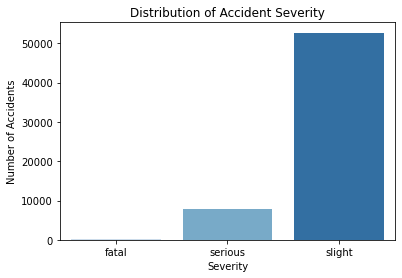

In [6]:
sns.countplot(x='Severity', data=df, palette='Blues')
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Number of Accidents')
plt.show()

This plot shows that the majority of bike accidents are not severe (slight) having only a few fatal cases.

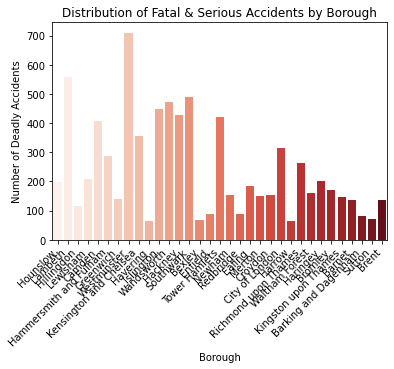

In [9]:
# Distribution of Fatal & Serious Accidents by Borough
serious_fatal = df[df['Severity'].isin(['fatal', 'serious'])]
sns.countplot(x='Borough', data=serious_fatal, palette='Reds')
plt.title('Distribution of Fatal & Serious Accidents by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Deadly Accidents')
plt.xticks(rotation=45, ha='right')
plt.show()

This plot shows use the regions (Borough) in which fatal and serious accidents had happened. As can be seen from the plot: Westminster has the highest number of accidents

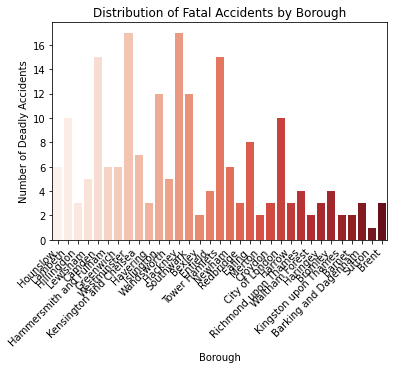

In [10]:
fatal = df[df['Severity'] == 'fatal']
sns.countplot(x='Borough', data=fatal, palette='Reds')
plt.title('Distribution of Fatal Accidents by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Deadly Accidents')
plt.xticks(rotation=45, ha='right')
plt.show()

This plot only shows the Borough in which FATAL cases had happened. As can be seen, most of the deadly accidents were in Westminster and Hackney regions

### Part 2: Model

In [11]:
df['DeadlyAccident'] = np.where(df['Severity'].isin(['fatal']), 1, 0) 

In [68]:
df['DeadlyAccident'].value_counts() # Fatal cases distribution (1 is fatal). Only 204 out of total

0    60443
1      204
Name: DeadlyAccident, dtype: int64

The percentage of fatal cases is 0.338% 

In [22]:
X = df.drop(columns=['Severity', 'Accident Index', 'Date'])  
y = df['Severity'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer( 
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]) # one-hot encoding for categorical features

In [27]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8683429513602638


Above is the model that identifies the factors contributing to ALL accidents in general. In order to deal with categorical variables, I have used one-hot encoding. The chosen model is logistic regression with maximum iterations set to 1000. Accuracy was used as the metric of evaluation for this model.

In [50]:
X = df.drop(columns=['Severity', 'DeadlyAccident'])
y = df['DeadlyAccident']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [51]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc2 = model.score(X_test, y_test)
print("Accuracy:", acc2)

Accuracy: 0.9969497114591921


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12093
           1       0.00      0.00      0.00        37

    accuracy                           1.00     12130
   macro avg       0.50      0.50      0.50     12130
weighted avg       0.99      1.00      1.00     12130



C:\Users\Nazira\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Nazira\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Nazira\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


The model is not performing well for deadly cases having the precision, recall, and F1-score all being 0. This is due to imbalance between classes: FATAL and SLIGHT/SERIOUS severity. Next on, I'll address this issue using SMOTE technique.

In [74]:
X = df.drop(columns=['Severity', 'DeadlyAccident', 'Accident Index', 'Date'])
y = df['DeadlyAccident']

In [72]:
# preprocessing numerical features: with scaling
numeric_features = ['Latitude', 'Longitude', 'cloud_cover', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'sunshine']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# preprocessing catgerical features with one-hot encoding
categorical_features = ['Borough', 'Ward', 'Traffic']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Preprocessing was applied using ColumnTransformer which handles categorical variables with OneHotEncoder. I used Logistic Regression as the model. SMOTE technique was used to deal with imbalanced classes.

In [77]:
model = make_pipeline(preprocessor, SMOTE(random_state=42), LogisticRegression())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = (y_pred == y_test).mean()
print("Accuracy:", accuracy)

Accuracy: 0.7267930750206101


C:\Users\Nazira\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.73      0.84     12093
           1       0.00      0.24      0.01        37

    accuracy                           0.73     12130
   macro avg       0.50      0.49      0.42     12130
weighted avg       0.99      0.73      0.84     12130



By looking into results of classification report above, we can see that there are slight improvements in such metrics as precision/recall and F1-score. Although, the overall accuracy of 0.73 is relatively high but is heavily influenced by the very small number of non-deadly accidents in the dataset.

### Part 3: Effect of stratification of Borough/Ward

In [83]:
X = df.drop(columns=['Severity', 'DeadlyAccident', 'Accident Index', 'Date'])
y = df['DeadlyAccident']

numeric_features = ['Latitude', 'Longitude', 'cloud_cover', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'sunshine']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Borough', 'Ward', 'Traffic']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [81]:
model = make_pipeline(preprocessor, SMOTE(random_state=42), LogisticRegression())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df[['Borough', 'Ward']])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = (y_pred == y_test).mean()
print("Accuracy:", accuracy)

Accuracy: 0.7453421269579554


C:\Users\Nazira\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stratification is done in train_test_split by using stratify() parameter above. 

In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.85     12087
           1       0.00      0.23      0.01        43

    accuracy                           0.75     12130
   macro avg       0.50      0.49      0.43     12130
weighted avg       0.99      0.75      0.85     12130



As an be seen, the stratification by Borough/Ward has brought to some changes when comparing to the previous case. To start with, the accuracy got a bit higher (from 0.72 to 0.74) meaning that overall model is peforming better. The recall for class 1 (deadly cases) is 0.24, which is, although, very low improvement. To sum up, there is a very slight improvement in accuracy and recall for predicting deadly cases after stratification of Borough/Ward.